In [1]:
import pandas as pd

In [2]:
file = r"raw_sports_cards.csv"
raw = pd.read_csv(file)

In [3]:
month_dict = {"Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4, "May": 5, "Jun": 6, 
              "Jul": 7, "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12}
year = 2020
prev_month = 3

def cleanup_date(raw_date):
    
    global month_dict, year, prev_month
    
    raw = str(raw_date)
    date, time = raw.split(' ')
    month, day = date.split('-')
    hour, minute = time.split(':')
    
    month = month_dict[month]
    
    if month == 12 and prev_month != 12:
        year -= 1
    try:
        result = pd.Period(month=month, year=year, freq='T',
                           day=int(day), hour=int(hour), minute=int(minute))
    except BaseException as e:
        print(e)
        print(raw)
        
    prev_month = month
    return result

In [4]:
raw["Time"] = raw["Time"].apply(cleanup_date)

In [5]:
raw[raw["Time"] > pd.Period("2020-01-01", "T")].to_csv(r"clean_data_2020.csv")

In [6]:
clean_data = raw[raw["Time"] > pd.Period("2020-01-01", "T")]
# clean_data = clean_data.set_index("Time").sort_index(ascending=False)

In [7]:
clean_data["Date"] = clean_data["Time"].apply(lambda x: pd.Period(x, "D"))

/Users/xionglihua/anaconda/envs/python3/lib/python3.5/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  """Entry point for launching an IPython kernel.


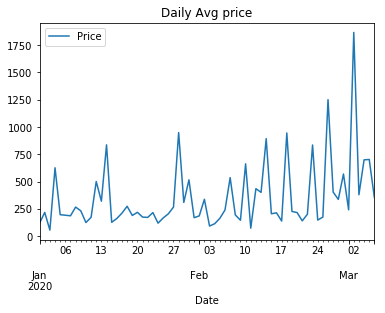

In [8]:
%matplotlib inline
clean_data.groupby("Date").mean().plot(title="Daily Avg price")

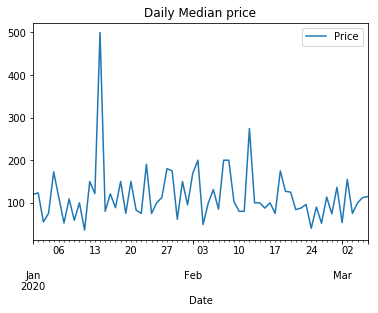

In [9]:
clean_data.groupby("Date").median().plot(title="Daily Median price")

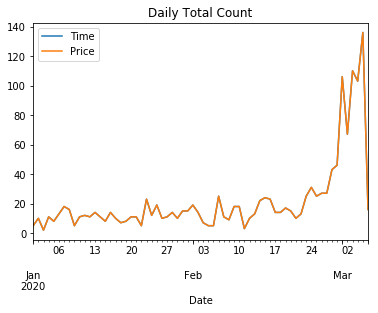

In [10]:
clean_data.groupby("Date").count().plot(title="Daily Total Count")